## Linear Regression from Sratch and Application

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

### Linear Regression

In [101]:
def hipothesis(x, w):
    return np.dot(x, w)

def mean_squared_error(h, y):
    return (1/y.shape[0]) * (np.sum((h - y) ** 2))

def gradient_error(h, y, x):
    return (2/y.shape[0]) * np.dot((h - y), x)

def gradient_descent(w, x, y, lr, n_iter):
    for i in range(n_iter):
        h = hipothesis(x, w)
        if (i + 1) % 10000 == 0:
            error = mean_squared_error_(h, y)
            print(f'Iteration {i + 1}, error: {error}')
        grad = gradient_error(h, y, x)
        w = w - lr*grad
    print(f'Parameters obtained: {w}')
    return w

### Importing and Exploring Data

In [81]:
df = pd.read_csv('./Housing.csv')

In [82]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [83]:
df.shape

(545, 13)

In [84]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [86]:
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


In [87]:
df.groupby('parking').mean(numeric_only=True).round(2)

,price,area,bedrooms,bathrooms,stories
parking,,,,,
0,4136016.72,4501.12,2.89,1.21,1.76
1,5190388.89,5576.36,2.98,1.35,1.90
2,5896328.15,6226.38,3.13,1.41,1.81
3,5867166.67,7178.33,3.25,1.50,2.00


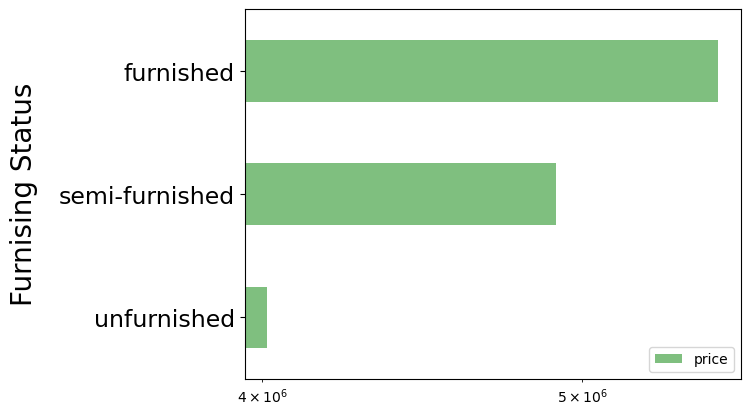

In [88]:
df_price_by_fs = df.groupby('furnishingstatus')[['price']].mean().sort_values('price')

plot = df_price_by_fs.plot(
    kind='barh', 
    color='green', 
    alpha=0.5
)

plot.set_xscale('log')
plot.set_ylabel('Furnising Status', fontsize=20, labelpad=15)
plot.tick_params(axis="y", labelsize=17)

In [89]:
(
    df[['bedrooms', 'stories', 'parking']]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .to_frame()
).query('proportion < 0.025')

proportion
bedrooms stories parking            
3        1       1          0.023853
         4       0          0.018349
                 2          0.012844
                 1          0.012844
4        4       1          0.011009
         1       0          0.011009
3        1       3          0.009174
         3       1          0.009174
5        2       0          0.009174
4        4       2          0.007339
2        2       1          0.007339
4        4       0          0.005505
         3       2          0.005505
                 0          0.005505
3        3       2          0.005505
5        2       2          0.003670
4        4       3          0.003670
1        1       0          0.003670
4        2       3          0.003670
2        1       3          0.001835
         4       0          0.001835
3        4       3          0.001835
         2       3          0.001835
4        1       1          0.001835
                 2          0.001835
         3       1          0.001835
5        1       1          0.001835
         2       1          0.001835
         3       0          0.001835
6        2       0          0.001835
                 1          0.001835

In [90]:
drop_indexes= (
    df
    .query('bedrooms == 5 | bedrooms == 6 | bedrooms == 1 | stories == 4 | stories == 3 | parking == 1')
    .index
)

df.drop(drop_indexes, axis=0, inplace=True)

In [91]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=float)

(
    df_encoded.corr().round(3)['price']
    .to_frame()
    .sort_values(by='price', ascending=False)
)

,price
price,1.000
area,0.492
parking,0.435
bathrooms,0.391
prefarea_yes,0.386
basement_yes,0.371
airconditioning_yes,0.350
bedrooms,0.331
guestroom_yes,0.311
mainroad_yes,0.246


In [92]:
df_encoded.drop(
    columns=['hotwaterheating_yes', 'furnishingstatus_semi-furnished', 'stories'], 
    inplace=True
)

In [93]:
X = df_encoded.iloc[:, 1:]
y = df_encoded.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

X_train = (X_train - X_train.mean()) / X_train.std(axis=0)
y_train = (y_train - y_train.mean()) / y_train.std(axis=0)

X_test = (X_test - X_train.mean()) / X_train.std(axis=0)

In [102]:
w_ = np.random.rand(X_train.shape[1]).astype('float32')
w = gradient_descent(w_, X_train, y_train, 0.001, 100000)

Iteration 10000, error: 0.397222297167678
Iteration 20000, error: 0.3972222969562311
Iteration 30000, error: 0.397222296956231
Iteration 40000, error: 0.39722229695623107
Iteration 50000, error: 0.39722229695623107
Iteration 60000, error: 0.39722229695623107
Iteration 70000, error: 0.39722229695623107
Iteration 80000, error: 0.39722229695623107
Iteration 90000, error: 0.39722229695623107
Iteration 100000, error: 0.39722229695623107
Parameters obtained: [ 0.27564754  0.08950197  0.25179319  0.15467936  0.06183033  0.06282575
  0.12171478  0.18835942  0.17785684 -0.16632626]


## Comparing with Sklearn

In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
reg = LinearRegression().fit(X_train, y_train)

In [97]:
mean_squared_error(reg.predict(X_test), y_test)

np.float64(20896243751782.914)

In [98]:
mean_squared_error(hipothesis(X_test, w), y_test)

np.float64(20896243751782.914)